In [2]:
import numpy as np 
import pandas as pd 
import xarray as xr
import geopandas as gpd
import rioxarray as rxr
import pickle
from pathlib import Path
import altair as alt
import matplotlib.pyplot as plt
import xskillscore

In [3]:
atl06sr_gdf = pickle.load(open('../data/icesat2/sierras_gdf_2018_2021_sa_processed_masked.pkl', 'rb'))

In [4]:
sierras = gpd.read_file('../data/misc/sierras_polygon_gmba.geojson')

In [5]:
# use open_mfdataset to open all years of swe/sca data at once, then open all sd data at once, and merge the two datasets saving the output file

base_dir = '../swe_reanalysis_pca/data/download'

swe_sca_files = []
sd_files = []

for year in range(2019, 2022):
    year_folder = Path(base_dir) / str(year)
    swe_sca_files.append(f"{base_dir}/{year}/SWE_SCA_POST_{year}.nc")
    sd_files.append(f"{base_dir}/{year}/SD_POST_{year}.nc")

def preprocess_swe(ds):
    ds = ds.rename({'Latitude': 'y', 'Longitude': 'x'})
    ds = ds.rio.set_spatial_dims('y', 'x', inplace=True)
    return ds

swe_sca_ds = xr.open_mfdataset(
    swe_sca_files,
    combine='by_coords',
    preprocess=preprocess_swe
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)


sd_ds = xr.open_mfdataset(
    sd_files,
    combine='by_coords'
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)

swe_sca_ds['SD_Post'] = sd_ds['SD_Post']


# swe_sca_ds = swe_sca_ds.rename({'Latitude': 'y', 'Longitude': 'x'})
# swe_sca_ds = swe_sca_ds.rio.set_spatial_dims('y', 'x', inplace=True)
swe_sca_ds['SWE_Post'] = swe_sca_ds['SWE_Post'].T
swe_sca_ds['SCA_Post'] = swe_sca_ds['SCA_Post'].T
swe_sca_ds = swe_sca_ds.transpose('time', 'y', 'x')
swe_sca_ds.rio.write_crs('EPSG:4326', inplace=True)
#swe_sca_ds['SD_Post'] = swe_sca_ds['SD_Post'].T

<xarray.Dataset> Size: 23GB
Dimensions:      (time: 1096, y: 1575, x: 1125)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 9kB 2018-10-01 2018-10-02 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SCA_Post     (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SD_Post      (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>

In [25]:
# use open_mfdataset to open all years of swe/sca data at once, then open all sd data at once, and merge the two datasets saving the output file

base_dir = '../swe_reanalysis_pca/data/download'

swe_sca_files = []
sd_files = []

for year in range(1985, 2022):
    year_folder = Path(base_dir) / str(year)
    swe_sca_files.append(f"{base_dir}/{year}/SWE_SCA_POST_{year}.nc")
    sd_files.append(f"{base_dir}/{year}/SD_POST_{year}.nc")

def preprocess_swe(ds):
    ds = ds.rename({'Latitude': 'y', 'Longitude': 'x'})
    ds = ds.rio.set_spatial_dims('y', 'x', inplace=True)
    return ds

swe_sca_ds_allyrs = xr.open_mfdataset(
    swe_sca_files,
    combine='by_coords',
    preprocess=preprocess_swe,
    chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)


sd_ds_allyrs = xr.open_mfdataset(
    sd_files,
    combine='by_coords',
    chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)

swe_sca_ds_allyrs['SD_Post'] = sd_ds_allyrs['SD_Post']


# swe_sca_ds = swe_sca_ds.rename({'Latitude': 'y', 'Longitude': 'x'})
# swe_sca_ds = swe_sca_ds.rio.set_spatial_dims('y', 'x', inplace=True)
swe_sca_ds_allyrs['SWE_Post'] = swe_sca_ds_allyrs['SWE_Post'].T
swe_sca_ds_allyrs['SCA_Post'] = swe_sca_ds_allyrs['SCA_Post'].T
swe_sca_ds_allyrs = swe_sca_ds_allyrs.transpose('time', 'y', 'x')
swe_sca_ds_allyrs.rio.write_crs('EPSG:4326', inplace=True)
#swe_sca_ds['SD_Post'] = swe_sca_ds['SD_Post'].T

<xarray.Dataset> Size: 287GB
Dimensions:      (time: 13514, y: 1575, x: 1125)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 108kB 1984-10-01 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, y, x) float32 96GB dask.array<chunksize=(365, 1575, 1125), meta=np.ndarray>
    SCA_Post     (time, y, x) float32 96GB dask.array<chunksize=(365, 1575, 1125), meta=np.ndarray>
    SD_Post      (time, y, x) float32 96GB dask.array<chunksize=(365, 263, 188), meta=np.ndarray>

In [26]:
swe_sca_ds_allyrs = swe_sca_ds_allyrs.rio.clip(sierras.geometry)

In [27]:
swe_sca_ds_allyrs = swe_sca_ds_allyrs.rename({'y': 'lat', 'x': 'lon'})

In [9]:
swe_sca_ds_allyrs

<xarray.Dataset> Size: 189GB
Dimensions:      (lat: 1267, lon: 919, time: 13514)
Coordinates:
  * lat          (lat) float32 5kB 34.82 34.82 34.83 34.83 ... 40.44 40.44 40.45
  * lon          (lon) float32 4kB -121.9 -121.9 -121.9 ... -117.9 -117.9 -117.9
  * time         (time) datetime64[ns] 108kB 1984-10-01 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, lat, lon) float32 63GB dask.array<chunksize=(61, 79, 176), meta=np.ndarray>
    SCA_Post     (time, lat, lon) float32 63GB dask.array<chunksize=(61, 79, 176), meta=np.ndarray>
    SD_Post      (time, lat, lon) float32 63GB dask.array<chunksize=(61, 79, 176), meta=np.ndarray>

In [10]:
atl06sr_gdf_sca_slope = atl06sr_gdf[(atl06sr_gdf['reanalysis_sca']> 0.9) & (atl06sr_gdf['slope'] < 20)]
atl06sr_gdf_sca_slope['n'] = atl06sr_gdf_sca_slope.groupby('acqdate')['acqdate'].transform('count')
atl06sr_gdf_sca_slope_n = atl06sr_gdf_sca_slope[atl06sr_gdf_sca_slope['n']> 100]

/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [11]:
medians = atl06sr_gdf_sca_slope_n[['icesat2_3dep_dif', 'acqdate','n', 'offset_sd', 'dowy']].dropna().groupby('acqdate').median()

In [12]:
medians

,icesat2_3dep_dif,n,offset_sd,dowy
acqdate,,,,
2018-12-03,0.313580,9551.0,0.084249,64.0
2018-12-07,0.507532,7902.0,0.015163,68.0
2018-12-11,0.449129,13618.0,0.094104,72.0
2018-12-12,0.441805,8327.0,0.086503,73.0
2018-12-15,-0.112512,947.0,-0.175992,76.0
...,...,...,...,...
2021-04-13,0.882264,525.0,0.024105,195.0
2021-04-17,1.064047,382.0,0.221101,199.0
2021-05-06,0.124651,131.0,-0.512325,218.0


In [13]:
medians['acqdate_dt'] = pd.to_datetime(medians.index)

In [14]:
medians['acqdate_dt'].dt.year

acqdate
2018-12-03    2018
2018-12-07    2018
2018-12-11    2018
2018-12-12    2018
2018-12-15    2018
              ... 
2021-04-13    2021
2021-04-17    2021
2021-05-06    2021
2021-05-08    2021
2021-05-10    2021
Name: acqdate_dt, Length: 120, dtype: int32

In [15]:
atl06sr_gdf_sca_slope_n['acqdate_dt'] = pd.to_datetime(atl06sr_gdf_sca_slope_n['acqdate'])

/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


### To do:  
* exclude current year from analysis
* calculate median snow depth from all icesat2 on a date
* for every year in the reanalysis library, sample at each icesat2 point and calculate the median snow depth  
* calculate the median snow depth from these sampled points  
* calculate the MAE for this date (this would use all points, not the median) or just total difference between medians  
* store these values in a dataframe that indexes (or just also contains) the year label
* rank these values and get the year with the best metric (but we also care about the other rankings)  
* then we could compare the current-year reanlaysis snow depth (or swe) to that of the best analog as a first pass  
* this will be a good check on our methods. then we should progress to using fsca, and maybe play with how to combine analogs. only start simulating icesat2 data if we think it's worth it/we need to.

In [16]:
medians['acqdate_dt']

acqdate
2018-12-03   2018-12-03
2018-12-07   2018-12-07
2018-12-11   2018-12-11
2018-12-12   2018-12-12
2018-12-15   2018-12-15
                ...    
2021-04-13   2021-04-13
2021-04-17   2021-04-17
2021-05-06   2021-05-06
2021-05-08   2021-05-08
2021-05-10   2021-05-10
Name: acqdate_dt, Length: 120, dtype: datetime64[ns]

In [17]:
date = pd.to_datetime('2021-04-07')
swe_sca_ds_allyrs.sel(time=date)

<xarray.Dataset> Size: 14MB
Dimensions:      (lat: 1267, lon: 919)
Coordinates:
  * lat          (lat) float32 5kB 34.82 34.82 34.83 34.83 ... 40.44 40.44 40.45
  * lon          (lon) float32 4kB -121.9 -121.9 -121.9 ... -117.9 -117.9 -117.9
    time         datetime64[ns] 8B 2021-04-07
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (lat, lon) float32 5MB dask.array<chunksize=(79, 176), meta=np.ndarray>
    SCA_Post     (lat, lon) float32 5MB dask.array<chunksize=(79, 176), meta=np.ndarray>
    SD_Post      (lat, lon) float32 5MB dask.array<chunksize=(79, 176), meta=np.ndarray>

In [18]:
date

Timestamp('2021-04-07 00:00:00')

In [19]:
latitudes = xr.DataArray(atl06sr_gdf_sca_slope_n.loc[atl06sr_gdf_sca_slope_n['acqdate_dt']==date].to_crs('epsg:4326').geometry.y.values, dims="points")
longitudes = xr.DataArray(atl06sr_gdf_sca_slope_n.loc[atl06sr_gdf_sca_slope_n['acqdate_dt']==date].to_crs('epsg:4326').geometry.x.values, dims="points")

In [31]:
swe_sca_ds

<xarray.Dataset> Size: 23GB
Dimensions:      (time: 1096, y: 1575, x: 1125)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 9kB 2018-10-01 2018-10-02 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SCA_Post     (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SD_Post      (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>

In [32]:
swe_sca_ds = swe_sca_ds.rename({'y': 'lat', 'x': 'lon'})

In [67]:
reanalysis_year.SD_Post

<xarray.DataArray 'SD_Post' (lat: 1575, lon: 1125, time: 365)> Size: 3GB
[646734375 values with dtype=float32]
Coordinates:
  * time         (time) datetime64[ns] 3kB 1984-10-01 1984-10-02 ... 1985-09-30
  * lat          (lat) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * lon          (lon) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
    spatial_ref  int64 8B ...
Attributes:
    Units:    meters

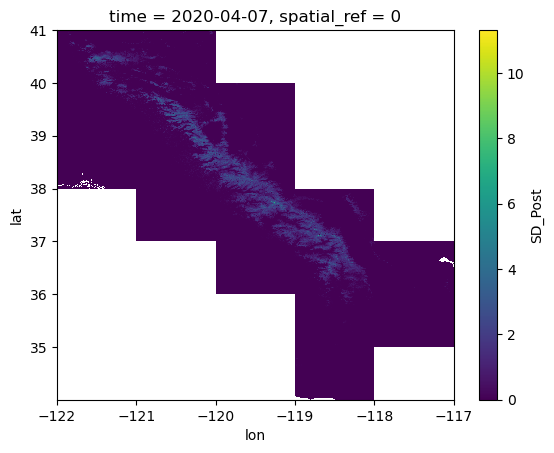

In [104]:
reanalysis_year.SD_Post.sel(time=sample_date).plot()

In [82]:
day = date.day
month = date.month
years = np.arange(1985,2022)
years_ex = years[years != date.year]

reanalysis_yoi = xr.open_dataset('../swe_reanalysis_pca/data/download/{}/SWE_SCA_SD_POST_{}.nc'.format(date.year,date.year))
reanalysis_yoi = reanalysis_yoi.rename({'y': 'lat', 'x': 'lon'})

icesat2_match = []

for y in years_ex:
    reanalysis_year = xr.open_dataset('../swe_reanalysis_pca/data/download/{}/SWE_SCA_SD_POST_{}.nc'.format(y,y))
    reanalysis_year = reanalysis_year.rename({'y': 'lat', 'x': 'lon'})
    sample_date = pd.Timestamp(year=y, month=month, day=day)
    sampled_sd = reanalysis_year.SD_Post.sel(time=sample_date).sel(lat=latitudes, lon=longitudes, method='nearest')
    icesat2_match.append({'year':y,'median_reanalysis':np.median(sampled_sd.values), 
                          'r2':xskillscore.r2(reanalysis_yoi.SD_Post.sel(time=date), reanalysis_year.SD_Post.sel(time=sample_date), dim=["lat", "lon"], skipna=True).values.item(),
                          'pearson_r':xskillscore.pearson_r(reanalysis_yoi.SD_Post.sel(time=date), reanalysis_year.SD_Post.sel(time=sample_date), dim=["lat", "lon"], skipna=True).values.item(),
                          'nmad':1.4826*(xskillscore.median_absolute_error(reanalysis_yoi.SD_Post.sel(time=date), reanalysis_year.SD_Post.sel(time=sample_date), dim=["lat", "lon"], skipna=True).values.item()),
                          'pbias':((np.nansum(reanalysis_year.SD_Post.sel(time=sample_date) - reanalysis_yoi.SD_Post.sel(time=date)) / np.nansum(reanalysis_yoi.SD_Post.sel(time=date)))*100),
                          'pbias_volume':((np.nansum(reanalysis_year.SWE_Post.sel(time=sample_date) - reanalysis_yoi.SWE_Post.sel(time=date)) / np.nansum(reanalysis_yoi.SWE_Post.sel(time=date)))*100),
                          'rmse':xskillscore.rmse(reanalysis_yoi.SD_Post.sel(time=date), reanalysis_year.SD_Post.sel(time=sample_date), dim=["lat", "lon"], skipna=True).values.item()})


In [100]:
from datetime import date, timedelta

In [ ]:
day = date.day
month = date.month
years = np.arange(1985,2022)
years_ex = years[years != date.year]

reanalysis_yoi = xr.open_dataset('../swe_reanalysis_pca/data/download/{}/SWE_SCA_SD_POST_{}.nc'.format(date.year,date.year))
reanalysis_yoi = reanalysis_yoi.rename({'y': 'lat', 'x': 'lon'})

icesat2_match = []

for y in years_ex:
    reanalysis_year = xr.open_dataset('../swe_reanalysis_pca/data/download/{}/SWE_SCA_SD_POST_{}.nc'.format(y,y))
    reanalysis_year = reanalysis_year.rename({'y': 'lat', 'x': 'lon'})
    sample_date = date(y, month, day)
    for i in range(-7,8):
        window_day = sample_date + timedelta(days=i)
        sampled_sd = reanalysis_year.SD_Post.sel(time=window_day).sel(lat=latitudes, lon=longitudes, method='nearest')
        icesat2_match.append({'year':y,'median_reanalysis':np.median(sampled_sd.values), 
                            #'r2':xskillscore.r2(reanalysis_yoi.SD_Post.sel(time=date), reanalysis_year.SD_Post.sel(time=window_day), dim=["lat", "lon"], skipna=True).values.item(),
                            'pearson_r':xskillscore.pearson_r(reanalysis_yoi.SD_Post.sel(time=date), reanalysis_year.SD_Post.sel(time=window_day), dim=["lat", "lon"], skipna=True).values.item(),
                            'nmad':1.4826*(xskillscore.median_absolute_error(reanalysis_yoi.SD_Post.sel(time=date), reanalysis_year.SD_Post.sel(time=window_day), dim=["lat", "lon"], skipna=True).values.item()),
                            'pbias':((np.nansum(reanalysis_year.SD_Post.sel(time=window_day) - reanalysis_yoi.SD_Post.sel(time=date)) / np.nansum(reanalysis_yoi.SD_Post.sel(time=date)))*100),
                            'pbias_volume':((np.nansum(reanalysis_year.SWE_Post.sel(time=window_day) - reanalysis_yoi.SWE_Post.sel(time=date)) / np.nansum(reanalysis_yoi.SWE_Post.sel(time=date)))*100),
                            'rmse':xskillscore.rmse(reanalysis_yoi.SD_Post.sel(time=date), reanalysis_year.SD_Post.sel(time=window_day), dim=["lat", "lon"], skipna=True).values.item()})


In [ ]:
# could use spearman's r 

In [89]:
icesat2_match_df = pd.DataFrame(icesat2_match)

In [90]:
icesat2_match_df['icesat2_median'] = medians.loc[date.date(), 'icesat2_3dep_dif']

In [91]:
icesat2_match_df['dif'] = icesat2_match_df['median_reanalysis'] - icesat2_match_df['icesat2_median']

In [92]:
icesat2_match_df['dif_abs'] = icesat2_match_df['dif'].abs()

In [93]:
icesat2_match_df['ranking_abs'] = icesat2_match_df['dif_abs'].rank()

In [94]:
icesat2_match_df


,year,median_reanalysis,r2,pearson_r,nmad,pbias,pbias_volume,rmse,icesat2_median,dif,dif_abs,ranking_abs
0,1985,1.7970,-0.366592,0.839955,0.0,115.592102,107.111237,0.324160,0.571352,1.225648,1.225648,21.0
1,1986,3.6690,-4.669995,0.826424,0.0,244.919891,240.122437,0.660285,0.571352,3.097648,3.097648,33.0
2,1987,1.5922,0.464481,0.837319,0.0,37.100517,21.502111,0.202921,0.571352,1.020848,1.020848,17.0
3,1988,0.8624,0.671450,0.837310,0.0,-37.045135,-28.367996,0.158943,0.571352,0.291048,0.291048,3.0
4,1989,1.4546,0.368899,0.886843,0.0,58.897591,59.617920,0.220287,0.571352,0.883248,0.883248,13.0
5,1990,0.9220,0.751072,0.868599,0.0,-20.116966,-17.760853,0.138349,0.571352,0.350648,0.350648,5.0
6,1991,2.0058,-0.652618,0.814927,0.0,171.712830,138.348602,0.356473,0.571352,1.434448,1.434448,23.0
7,1992,1.4302,0.154300,0.770731,0.0,68.769249,59.133148,0.255005,0.571352,0.858848,0.858848,11.0
8,1993,4.0280,-7.745482,0.834022,0.0,406.834473,419.038483,0.820034,0.571352,3.456648,3.456648,36.0
9,1994,0.8932,0.738803,0.863674,0.0,1.532988,0.968345,0.141718,0.571352,0.321848,0.321848,4.0


Text(0, 0.5, 'R2')

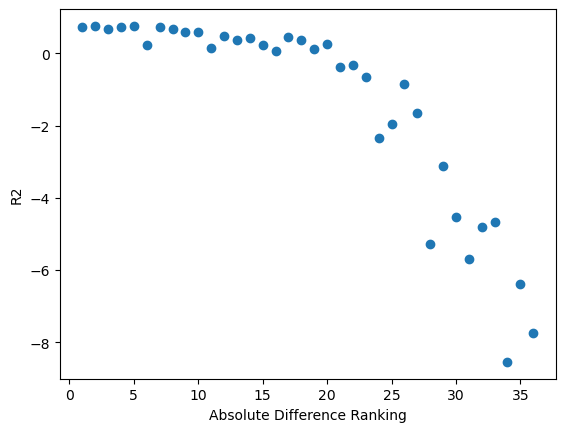

In [95]:
fig, ax = plt.subplots()
plt.scatter(icesat2_match_df['ranking_abs'], icesat2_match_df['r2'])
plt.xlabel('Absolute Difference Ranking')
plt.ylabel('R2')

Text(0, 0.5, 'Pearson R')

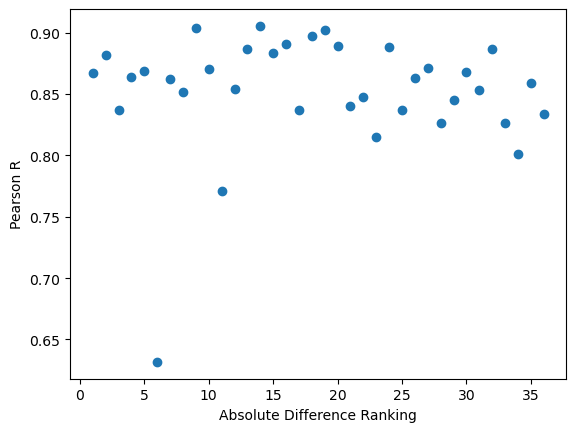

In [98]:
fig, ax = plt.subplots()
plt.scatter(icesat2_match_df['ranking_abs'], icesat2_match_df['pearson_r'])
plt.xlabel('Absolute Difference Ranking')
plt.ylabel('Pearson R')

Text(0, 0.5, 'Pbias')

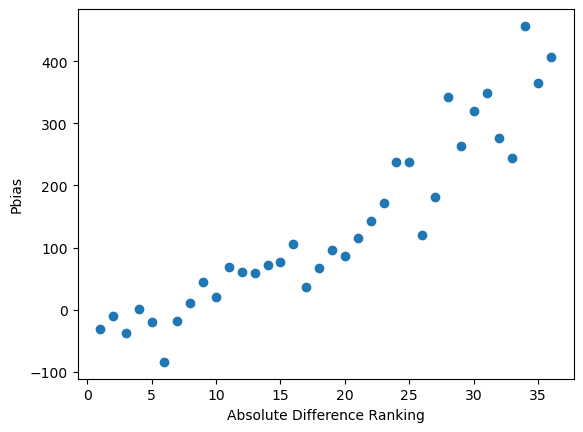

In [79]:
fig, ax = plt.subplots()
plt.scatter(icesat2_match_df['ranking_abs'], icesat2_match_df['pbias'])
plt.xlabel('Absolute Difference Ranking')
plt.ylabel('Pbias')

Text(0, 0.5, 'Pbias volume')

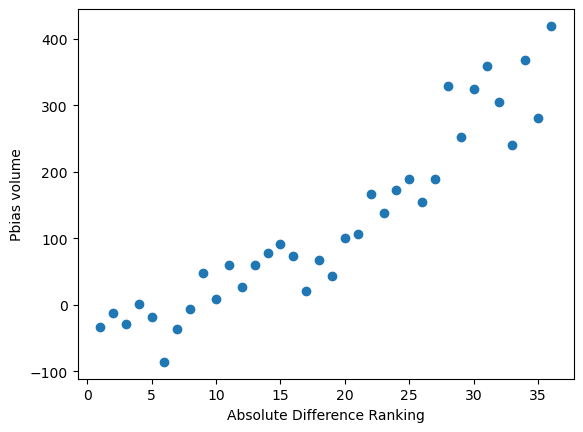

In [97]:
fig, ax = plt.subplots()
plt.scatter(icesat2_match_df['ranking_abs'], icesat2_match_df['pbias_volume'])
plt.xlabel('Absolute Difference Ranking')
plt.ylabel('Pbias volume')

Text(0, 0.5, 'Pbias')

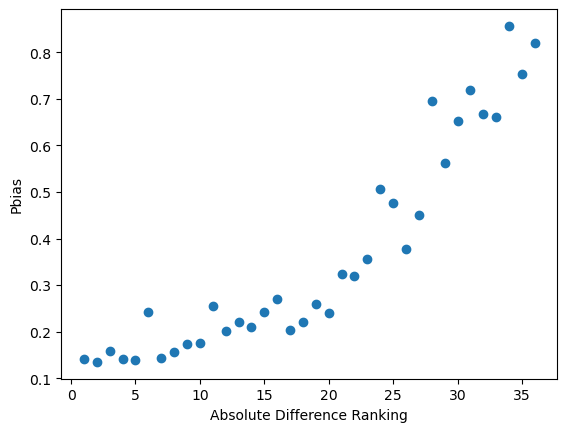

In [99]:
fig, ax = plt.subplots()
plt.scatter(icesat2_match_df['ranking_abs'], icesat2_match_df['rmse'])
plt.xlabel('Absolute Difference Ranking')
plt.ylabel('Pbias')

In [216]:
sample_date = pd.Timestamp(year=2007, month=date.month, day=date.day)
rank1_dif = swe_sca_ds_allyrs.SD_Post.sel(time=sample_date) - swe_sca_ds_allyrs.SD_Post.sel(time=date)

In [223]:
sample_date

Timestamp('2007-04-07 00:00:00')

In [218]:
date

Timestamp('2021-04-07 00:00:00')

Text(0.5, 1.0, '2007-04-07 00:00:00 - 2021-04-07 00:00:00')

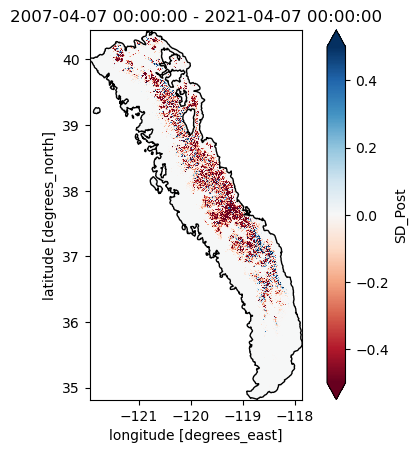

In [224]:
fig, ax = plt.subplots()
rank1_dif.plot(ax=ax, cmap='RdBu', vmin=-0.5, vmax=0.5)
sierras.plot(ax=ax, facecolor='none', edgecolor='black')
plt.title(f'{sample_date} - {date}')

### next: calculate the difference between the date of interest and all other years, see if the rank1 from icesat2 matches the rank1 from the reanalysis options  
-> having issues here with too many 0s, which makes the differences between years across all sierra nevada quite small. Instead of summing all the areas, just use the sampled icesat2 area (so locations from icesat2, but comparing only data from the reanalysis)

In [201]:
# day = date.day
# month = date.month
# years = np.arange(1985,2022)
# years_ex = years[years != date.year]

# reanalysis_dif = []

# for y in years_ex:
#     sample_date = pd.Timestamp(year=y, month=month, day=day)
#     print(sample_date)
#     sd_dif = swe_sca_ds_allyrs.SD_Post.sel(time=sample_date) - swe_sca_ds_allyrs.SD_Post.sel(time=date)
#     reanalysis_dif.append({'year':y,'reanalysis_difference':np.nanmedian(sd_dif.values)})


1985-04-07 00:00:00
1986-04-07 00:00:00
1987-04-07 00:00:00
1988-04-07 00:00:00
1989-04-07 00:00:00
1990-04-07 00:00:00
1991-04-07 00:00:00
1992-04-07 00:00:00
1993-04-07 00:00:00
1994-04-07 00:00:00
1995-04-07 00:00:00
1996-04-07 00:00:00
1997-04-07 00:00:00
1998-04-07 00:00:00
1999-04-07 00:00:00
2000-04-07 00:00:00
2001-04-07 00:00:00
2002-04-07 00:00:00
2003-04-07 00:00:00
2004-04-07 00:00:00
2005-04-07 00:00:00
2006-04-07 00:00:00
2007-04-07 00:00:00
2008-04-07 00:00:00
2009-04-07 00:00:00
2010-04-07 00:00:00
2011-04-07 00:00:00
2012-04-07 00:00:00
2013-04-07 00:00:00
2014-04-07 00:00:00
2015-04-07 00:00:00
2016-04-07 00:00:00
2017-04-07 00:00:00
2018-04-07 00:00:00
2019-04-07 00:00:00
2020-04-07 00:00:00


In [ ]:
sampled_sd = swe_sca_ds_allyrs.SD_Post.sel(time=sample_date).sel(lat=latitudes, lon=longitudes, method='nearest')
reanalysis_medians.append({'year':y,'median_reanalysis':np.median(sampled_sd.values)})

In [202]:
day = date.day
month = date.month
years = np.arange(1985,2022)
years_ex = years[years != date.year]
sampled_date = swe_sca_ds_allyrs.SD_Post.sel(time=date).sel(lat=latitudes, lon=longitudes, method='nearest')

reanalysis_dif = []

for y in years_ex:
    other_date = pd.Timestamp(year=y, month=month, day=day)
    print(sample_date)
    sampled_other_date = swe_sca_ds_allyrs.SD_Post.sel(time=other_date).sel(lat=latitudes, lon=longitudes, method='nearest')
    sd_dif = sampled_other_date - sampled_date
    reanalysis_dif.append({'year':y,'reanalysis_difference':np.nanmedian(sd_dif.values)})


2020-04-07 00:00:00
2020-04-07 00:00:00
2020-04-07 00:00:00
2020-04-07 00:00:00
2020-04-07 00:00:00
2020-04-07 00:00:00
2020-04-07 00:00:00
2020-04-07 00:00:00
2020-04-07 00:00:00
2020-04-07 00:00:00
2020-04-07 00:00:00
2020-04-07 00:00:00
2020-04-07 00:00:00
2020-04-07 00:00:00
2020-04-07 00:00:00
2020-04-07 00:00:00
2020-04-07 00:00:00
2020-04-07 00:00:00
2020-04-07 00:00:00
2020-04-07 00:00:00
2020-04-07 00:00:00
2020-04-07 00:00:00
2020-04-07 00:00:00
2020-04-07 00:00:00
2020-04-07 00:00:00
2020-04-07 00:00:00
2020-04-07 00:00:00
2020-04-07 00:00:00
2020-04-07 00:00:00
2020-04-07 00:00:00
2020-04-07 00:00:00
2020-04-07 00:00:00
2020-04-07 00:00:00
2020-04-07 00:00:00
2020-04-07 00:00:00
2020-04-07 00:00:00


In [203]:
reanalysis_match_df = pd.DataFrame(reanalysis_dif)

In [204]:
reanalysis_match_df

,year,reanalysis_difference
0,1985,0.7914
1,1986,2.6722
2,1987,0.5518
3,1988,-0.2028
4,1989,0.4060
5,1990,-0.1506
6,1991,0.9186
7,1992,0.4522
8,1993,2.9864
9,1994,-0.1166


In [205]:
reanalysis_match_df['dif_abs'] = reanalysis_match_df['reanalysis_difference'].abs()

In [206]:
reanalysis_match_df['ranking_abs'] = reanalysis_match_df['dif_abs'].rank()

In [207]:
reanalysis_match_df

,year,reanalysis_difference,dif_abs,ranking_abs
0,1985,0.7914,0.7914,20.0
1,1986,2.6722,2.6722,33.0
2,1987,0.5518,0.5518,14.0
3,1988,-0.2028,0.2028,6.0
4,1989,0.4060,0.4060,10.0
5,1990,-0.1506,0.1506,4.0
6,1991,0.9186,0.9186,23.0
7,1992,0.4522,0.4522,12.0
8,1993,2.9864,2.9864,36.0
9,1994,-0.1166,0.1166,2.0


Text(0.5, 1.0, 'Reanalysis Ranking')

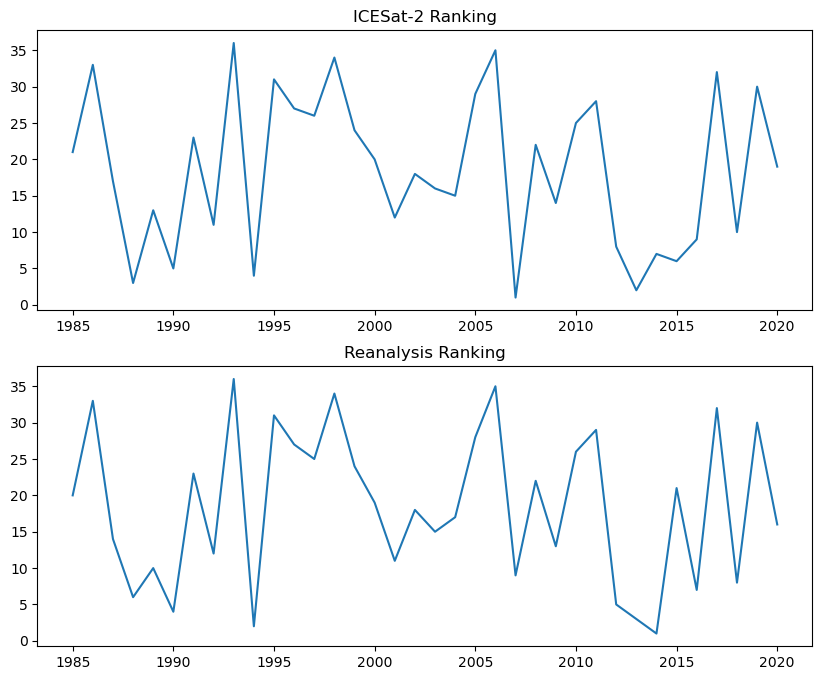

In [209]:
fig, ax = plt.subplots(2,1, figsize=(10,8))

ax[0].plot(icesat2_match_df['year'], icesat2_match_df['ranking_abs'])
ax[1].plot(reanalysis_match_df['year'], reanalysis_match_df['ranking_abs'])
ax[0].set_title('ICESat-2 Ranking')
ax[1].set_title('Reanalysis Ranking')

In [167]:
reanalysis_medians_df['ranking_abs'].sort_values()

22     1.0
28     2.0
3      3.0
9      4.0
5      5.0
36     6.0
30     7.0
29     8.0
27     9.0
31    10.0
33    11.0
7     12.0
16    13.0
4     14.0
24    15.0
19    16.0
18    17.0
2     18.0
17    19.0
35    20.0
15    21.0
0     22.0
23    23.0
6     24.0
14    25.0
25    26.0
12    27.0
11    28.0
26    29.0
20    30.0
34    31.0
10    32.0
32    33.0
1     34.0
13    35.0
21    36.0
8     37.0
Name: ranking_abs, dtype: float64

In [210]:
import scipy.stats as stats

In [211]:
stats.ranksums(reanalysis_match_df['ranking_abs'], icesat2_match_df['ranking_abs'])

RanksumsResult(statistic=np.float64(0.0), pvalue=np.float64(1.0))

In [212]:
icesat2_match_df['ranking_offset'] = icesat2_match_df['ranking_abs'] - reanalysis_match_df['ranking_abs']

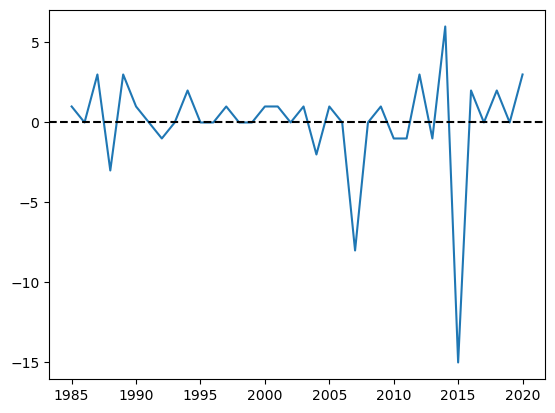

In [213]:
fig, ax = plt.subplots()
plt.plot(icesat2_match_df['year'], icesat2_match_df['ranking_offset'])
ax.axhline(0, color='k', linestyle='--')

Im compariong analogs, but should be comparing overall correlation between years. How do I do this with so much data?
also should expand my search window to 1-2 weeks around is2 track date